# Santos Comparison

This notebook follows the assignment directly: it diagonalizes the full $2^L$ Hilbert space for the periodic XXZ chain with $L=6$, then plots the first five energies, the ground-state total $M_z$, the ground-state fidelity on the negative-$\Delta$ branch only, and the ground-state half-chain entanglement entropy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8-whitegrid')


class FullXXZChain:
    """Periodic XXZ chain diagonalized in the full 2^L Hilbert space."""

    def __init__(self, L, Jxy=1.0, Delta=0.0, periodic=True):
        self.L = int(L)
        self.Jxy = float(Jxy)
        self.Delta = float(Delta)
        self.periodic = bool(periodic)
        self.dim = 1 << self.L
        self.states = np.arange(self.dim, dtype=np.uint64)
        self.pairs = self._pairs()
        self.mz_values = np.array([int(state).bit_count() - self.L / 2 for state in self.states], dtype=float)
        # Precompute sector index groups so diagonalization stays within each Sz block.
        # This prevents the eigensolver from mixing degenerate states across sectors,
        # which would produce non-integer Mz values and spurious fidelity dips at
        # the ferromagnetic (Delta=-1) and Neel (Delta=+1) phase boundaries.
        self._sectors = self._build_sectors()
        # Split H = Jxy * H_hop + Delta * diag(zz_nn) so Delta sweeps only update
        # the diagonal rather than rebuilding the full matrix from scratch each call.
        self._H_hop, self._zz_nn = self._build_hop_and_zz()

    def _pairs(self):
        if self.periodic:
            return [(i, (i + 1) % self.L) for i in range(self.L)]
        return [(i, i + 1) for i in range(self.L - 1)]

    def _build_sectors(self):
        """Return {2*Mz (int): array of basis indices} for each Sz sector."""
        mz2 = np.round(2 * self.mz_values).astype(int)
        sectors = {}
        for idx, key in enumerate(mz2):
            sectors.setdefault(key, []).append(idx)
        return {k: np.array(v) for k, v in sectors.items()}

    def _build_hop_and_zz(self):
        """Precompute the XY hopping matrix and NN Ising diagonal (both parameter-free)."""
        H_hop = np.zeros((self.dim, self.dim), dtype=float)
        zz_nn = np.zeros(self.dim, dtype=float)
        one = np.uint64(1)
        for i, state in enumerate(self.states):
            for left, right in self.pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    zz_nn[i] += 0.25
                else:
                    zz_nn[i] -= 0.25
                    flipped = state ^ ((one << bit_left) | (one << bit_right))
                    H_hop[i, int(flipped)] += 0.5
        return H_hop, zz_nn

    def build_hamiltonian(self):
        return self.Jxy * self._H_hop + np.diag(self.Delta * self._zz_nn)

    def diagonalize(self):
        """Diagonalize within each Sz sector to guarantee Sz-eigenstate eigenvectors."""
        H = self.build_hamiltonian()
        pairs = []
        for indices in self._sectors.values():
            H_block = H[np.ix_(indices, indices)]
            evals, evecs = np.linalg.eigh(H_block)
            for k in range(len(evals)):
                full = np.zeros(self.dim, dtype=float)
                full[indices] = evecs[:, k]
                pairs.append((evals[k], full))
        pairs.sort(key=lambda x: x[0])
        eigvals = np.array([p[0] for p in pairs])
        eigvecs = np.column_stack([p[1] for p in pairs])
        return eigvals, eigvecs

    def magnetization(self, state):
        probabilities = np.abs(state) ** 2
        return float(np.dot(probabilities, self.mz_values))

    def half_chain_entropy(self, state):
        ell = self.L // 2
        psi_matrix = state.reshape((1 << ell, 1 << (self.L - ell)))
        singular_values = np.linalg.svd(psi_matrix, compute_uv=False)
        probabilities = singular_values ** 2
        probabilities = probabilities[probabilities > 1e-14]
        return float(-np.sum(probabilities * np.log(probabilities)))


def fidelity(state_a, state_b):
    return float(np.abs(np.vdot(state_a, state_b)))

In [ ]:
# Full-space sweep for the periodic XXZ model at L = 6.
# Energies: first five eigenvalues for -1.5 <= Delta <= 1.5 in steps of 0.05.
# Magnetization: total Mz for the ground state on the same grid.
# Fidelity: consecutive ground-state overlaps on the negative-Delta branch only.
# Entanglement: ground-state half-chain entropy on the same grid.
L = 6
chain = FullXXZChain(L=L, Jxy=1.0, Delta=-1.5, periodic=True)

delta_values = np.linspace(-1.5, 1.5, 61)
energy_levels = []
mz_values = []
entropy_values = []
ground_states = []

for delta in delta_values:
    chain.Delta = float(delta)
    eigvals, eigvecs = chain.diagonalize()
    energy_levels.append(eigvals[:5])
    ground_state = eigvecs[:, 0]
    ground_states.append(ground_state)
    mz_values.append(chain.magnetization(ground_state))
    entropy_values.append(chain.half_chain_entropy(ground_state))

energy_levels = np.asarray(energy_levels, dtype=float)
mz_values = np.asarray(mz_values, dtype=float)
entropy_values = np.asarray(entropy_values, dtype=float)
ground_states = np.asarray(ground_states, dtype=complex)

zero_idx = int(np.where(np.isclose(delta_values, 0.0))[0][0])
# Plot each fidelity value at the midpoint of the two Delta points it connects,
# rather than at the right endpoint, to avoid a half-step x-axis shift.
delta_fidelity = (delta_values[:zero_idx - 1] + delta_values[1:zero_idx]) / 2
fidelity_values = np.array([
    fidelity(ground_states[i - 1], ground_states[i])
    for i in range(1, zero_idx)
], dtype=float)

print('computed', len(delta_values), 'Delta points for L =', L)
print('fidelity plotted for', len(delta_fidelity), 'points on the negative Delta branch')

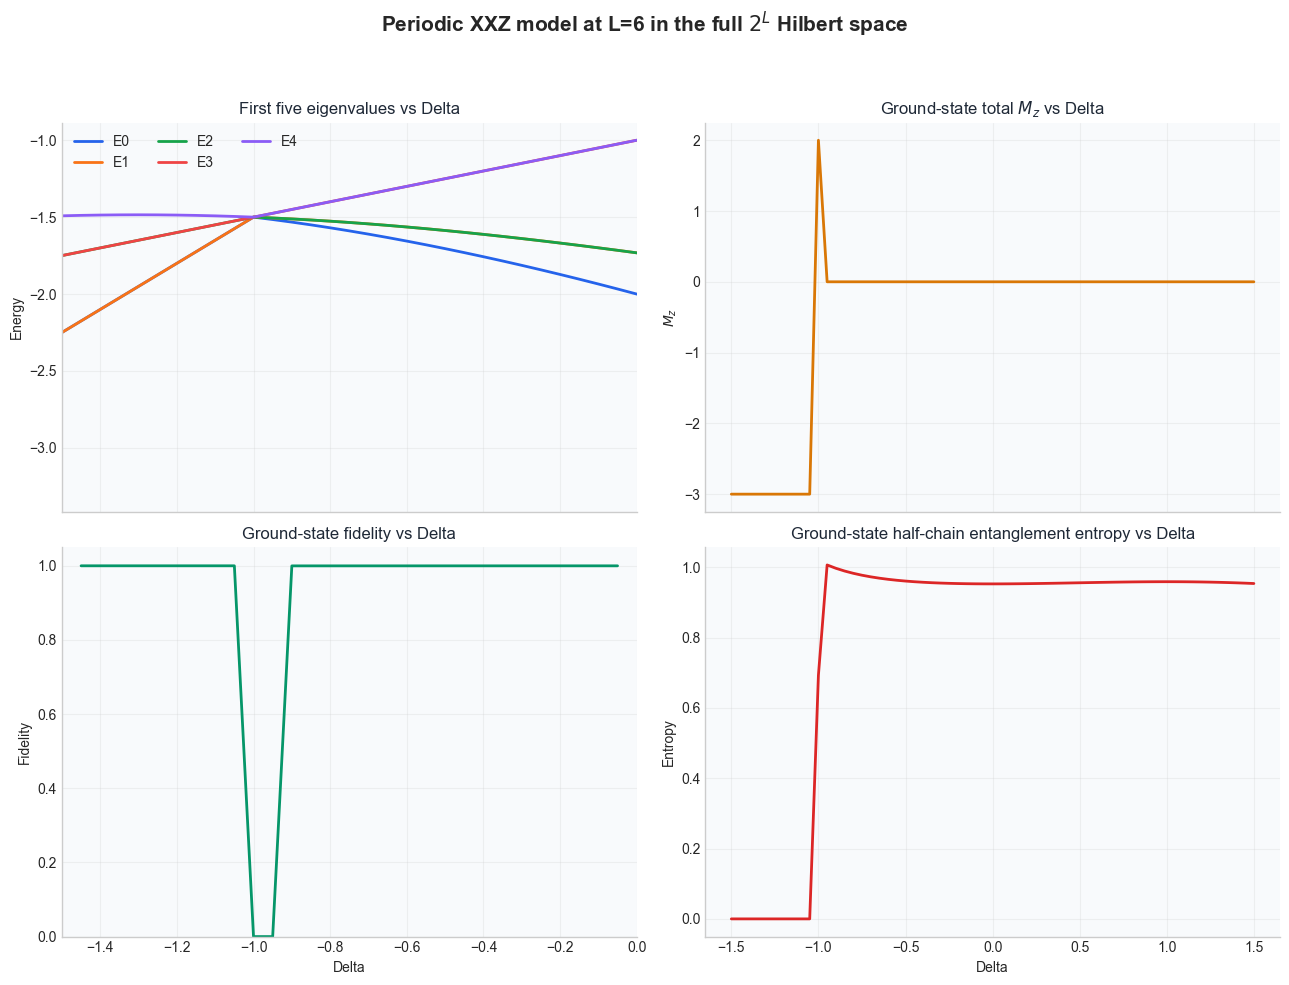

In [13]:
# Four-panel comparison plot versus Delta.
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex='col')
fig.patch.set_facecolor('white')
panel_color = '#1f2937'
accent_energy = '#2563eb'
accent_mz = '#d97706'
accent_fidelity = '#059669'
accent_entropy = '#dc2626'
level_colors = ['#2563eb', '#f97316', '#16a34a', '#ef4444', '#8b5cf6']


for level in range(5):
    axes[0, 0].plot(delta_values, energy_levels[:, level], label=f'E{level}', linewidth=2, color=level_colors[level])
axes[0, 0].set_title('First five eigenvalues vs Delta', color=panel_color)
axes[0, 0].set_ylabel('Energy')
axes[0, 0].legend(ncol=3, frameon=False)
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].set_facecolor('#f8fafc')

axes[0, 1].plot(delta_values, mz_values, color=accent_mz, linewidth=2)
axes[0, 1].set_title('Ground-state total $M_z$ vs Delta', color=panel_color)
axes[0, 1].set_ylabel('$M_z$')
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].set_facecolor('#f8fafc')

axes[1, 0].plot(delta_fidelity, fidelity_values, color=accent_fidelity, linewidth=2)
axes[1, 0].set_title('Ground-state fidelity vs Delta', color=panel_color)
axes[1, 0].set_xlabel('Delta')
axes[1, 0].set_ylabel('Fidelity')
axes[1, 0].set_xlim(-1.5, 0.0)
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].grid(True, alpha=0.25)
axes[1, 0].set_facecolor('#f8fafc')

axes[1, 1].plot(delta_values, entropy_values, color=accent_entropy, linewidth=2)
axes[1, 1].set_title('Ground-state half-chain entanglement entropy vs Delta', color=panel_color)
axes[1, 1].set_xlabel('Delta')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].grid(True, alpha=0.25)
axes[1, 1].set_facecolor('#f8fafc')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)

fig.suptitle(f'Periodic XXZ model at L={L} in the full $2^L$ Hilbert space', fontsize=15, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# 3D comparison panel over Delta and J2z.
# The energy panel shows the first five eigenvalue surfaces.
# Fidelity is the ground-state overlap between neighboring Delta points for each J2z slice.
from IPython.display import HTML, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class FullXXZChainJ2:
    """Periodic XXZ chain in the full 2^L Hilbert space with a next-nearest Ising term."""

    def __init__(self, L, Jxy=1.0, Delta=0.0, J2z=0.0, periodic=True):
        self.L = int(L)
        self.Jxy = float(Jxy)
        self.Delta = float(Delta)
        self.J2z = float(J2z)
        self.periodic = bool(periodic)
        self.dim = 1 << self.L
        self.states = np.arange(self.dim, dtype=np.uint64)
        self.nn_pairs = self._pairs(distance=1)
        self.nnn_pairs = self._pairs(distance=2)
        self.mz_values = np.array([int(state).bit_count() - self.L / 2 for state in self.states], dtype=float)
        self._sectors = self._build_sectors()
        # H = Jxy * H_hop + Delta * diag(zz_nn) + J2z * diag(zz_nnn).
        # All three parts are parameter-free and built once at construction.
        self._H_hop, self._zz_nn, self._zz_nnn = self._build_hop_and_zz()

    def _pairs(self, distance):
        if self.periodic:
            return [(i, (i + distance) % self.L) for i in range(self.L)]
        return [(i, i + distance) for i in range(self.L - distance)]

    def _build_sectors(self):
        mz2 = np.round(2 * self.mz_values).astype(int)
        sectors = {}
        for idx, key in enumerate(mz2):
            sectors.setdefault(key, []).append(idx)
        return {k: np.array(v) for k, v in sectors.items()}

    def _build_hop_and_zz(self):
        H_hop = np.zeros((self.dim, self.dim), dtype=float)
        zz_nn = np.zeros(self.dim, dtype=float)
        zz_nnn = np.zeros(self.dim, dtype=float)
        one = np.uint64(1)
        for i, state in enumerate(self.states):
            for left, right in self.nn_pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    zz_nn[i] += 0.25
                else:
                    zz_nn[i] -= 0.25
                    flipped = state ^ ((one << bit_left) | (one << bit_right))
                    H_hop[i, int(flipped)] += 0.5
            for left, right in self.nnn_pairs:
                bit_left = np.uint64(self.L - 1 - left)
                bit_right = np.uint64(self.L - 1 - right)
                occ_left = (state >> bit_left) & one
                occ_right = (state >> bit_right) & one
                if occ_left == occ_right:
                    zz_nnn[i] += 0.25
                else:
                    zz_nnn[i] -= 0.25
        return H_hop, zz_nn, zz_nnn

    def build_hamiltonian(self):
        diag = self.Delta * self._zz_nn + self.J2z * self._zz_nnn
        return self.Jxy * self._H_hop + np.diag(diag)

    def diagonalize(self):
        H = self.build_hamiltonian()
        pairs = []
        for indices in self._sectors.values():
            H_block = H[np.ix_(indices, indices)]
            evals, evecs = np.linalg.eigh(H_block)
            for k in range(len(evals)):
                full = np.zeros(self.dim, dtype=float)
                full[indices] = evecs[:, k]
                pairs.append((evals[k], full))
        pairs.sort(key=lambda x: x[0])
        eigvals = np.array([p[0] for p in pairs])
        eigvecs = np.column_stack([p[1] for p in pairs])
        return eigvals, eigvecs

    def magnetization(self, state):
        probabilities = np.abs(state) ** 2
        return float(np.dot(probabilities, self.mz_values))

    def half_chain_entropy(self, state):
        ell = self.L // 2
        psi_matrix = state.reshape((1 << ell, 1 << (self.L - ell)))
        singular_values = np.linalg.svd(psi_matrix, compute_uv=False)
        probabilities = singular_values ** 2
        probabilities = probabilities[probabilities > 1e-14]
        return float(-np.sum(probabilities * np.log(probabilities)))


delta_values_3d = np.linspace(-1.5, 1.5, 200)
j2z_values = np.linspace(-1.5, 1.5, 200)
energy_surfaces = [np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float) for _ in range(5)]
mz_surface = np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float)
entropy_surface = np.zeros((len(j2z_values), len(delta_values_3d)), dtype=float)
fidelity_surface = np.full((len(j2z_values), len(delta_values_3d)), np.nan, dtype=float)

# Single chain instance reused across all (Delta, J2z) pairs; H_hop and zz arrays
# are built once at construction and only the scalar coefficients change each iteration.
chain_3d = FullXXZChainJ2(L=6, Jxy=1.0, Delta=0.0, J2z=0.0, periodic=True)

for row, j2z in enumerate(j2z_values):
    chain_3d.J2z = float(j2z)
    previous_ground_state = None
    for col, delta in enumerate(delta_values_3d):
        chain_3d.Delta = float(delta)
        eigvals, eigvecs = chain_3d.diagonalize()
        for level in range(5):
            energy_surfaces[level][row, col] = eigvals[level]
        ground_state = eigvecs[:, 0]
        mz_surface[row, col] = chain_3d.magnetization(ground_state)
        entropy_surface[row, col] = chain_3d.half_chain_entropy(ground_state)
        if previous_ground_state is not None:
            fidelity_surface[row, col] = fidelity(previous_ground_state, ground_state)
        previous_ground_state = ground_state
    if (row + 1) % 20 == 0:
        print(f'  {row + 1}/{len(j2z_values)} J2z rows done')

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}], [{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=(
        'First five eigenvalues vs Delta and J2z',
        'Ground-state total Mz vs Delta and J2z',
        'Ground-state fidelity vs Delta and J2z',
        'Ground-state half-chain entanglement entropy vs Delta and J2z',
    ),
    vertical_spacing=0.08,
    horizontal_spacing=0.06,
)

surface_kwargs = dict(opacity=0.9, showscale=False)
energy_colors = ['#2563eb', '#f97316', '#16a34a', '#ef4444', '#8b5cf6']
for level in range(5):
    fig.add_trace(
        go.Surface(x=delta_values_3d, y=j2z_values, z=energy_surfaces[level], colorscale=[[0, energy_colors[level]], [1, energy_colors[level]]], opacity=0.55, showscale=False, name=f'E{level}'),
        row=1, col=1,
    )

fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=mz_surface, colorscale='Oranges', **surface_kwargs),
    row=1, col=2,
)
fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=fidelity_surface, colorscale='Greens', **surface_kwargs),
    row=2, col=1,
)
fig.add_trace(
    go.Surface(x=delta_values_3d, y=j2z_values, z=entropy_surface, colorscale='Reds', **surface_kwargs),
    row=2, col=2,
)

fig.update_layout(
    title=f'Periodic XXZ model at L=6 over Delta and J2z',
    height=1000,
    width=1300,
    margin=dict(l=10, r=10, t=60, b=10),
)

for scene_name in ['scene', 'scene2', 'scene3', 'scene4']:
    fig.layout[scene_name].xaxis.title = 'Delta'
    fig.layout[scene_name].yaxis.title = 'J2z'
    fig.layout[scene_name].zaxis.title = 'Value'

display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

In [ ]:
# Entanglement entropy surface S(Delta, J2z) for increasing chain length L.
# Full exact diagonalization: Hilbert dimension = 2^L.
#
# MEMORY SCALING WARNING: the dense Hamiltonian requires (2^L)^2 * 8 bytes.
#   L=12  dim=4096    ~128 MB  (safe)
#   L=14  dim=16384   ~2 GB    (likely crash)
#   L=16  dim=65536   ~32 GB   (will crash)
# Do not add L values beyond 12 without switching to a sparse / sector-only solver.

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

L_values = [4, 6, 8, 10, 12]
delta_values = np.linspace(-1.5, 1.5, 41)
j2z_values = np.linspace(-1.5, 1.5, 41)

Jxy = 1.0
periodic = True

entropy_surfaces_by_L = {}

for L in L_values:
    print(f"Computing entropy surface for L = {L}, Hilbert dimension = {2**L}")

    entropy_surface = np.zeros((len(j2z_values), len(delta_values)), dtype=float)

    # One chain per L; H_hop, zz_nn, zz_nnn built once and reused across all (delta, j2z).
    chain = FullXXZChainJ2(L=L, Jxy=Jxy, Delta=float(delta_values[0]), J2z=float(j2z_values[0]), periodic=periodic)

    for row, j2z in enumerate(j2z_values):
        chain.J2z = float(j2z)
        for col, delta in enumerate(delta_values):
            chain.Delta = float(delta)
            eigvals, eigvecs = chain.diagonalize()
            ground_state = eigvecs[:, 0]
            entropy_surface[row, col] = chain.half_chain_entropy(ground_state)

    entropy_surfaces_by_L[L] = entropy_surface

print("Done.")

n_cols = 2
n_rows = int(np.ceil(len(L_values) / n_cols))

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    specs=[[{"type": "surface"} for _ in range(n_cols)] for _ in range(n_rows)],
    subplot_titles=[f"L = {L}" for L in L_values],
    horizontal_spacing=0.06,
    vertical_spacing=0.08,
)

for idx, L in enumerate(L_values):
    row = idx // n_cols + 1
    col = idx % n_cols + 1

    fig.add_trace(
        go.Surface(
            x=delta_values,
            y=j2z_values,
            z=entropy_surfaces_by_L[L],
            colorscale="Viridis",
            showscale=(idx == len(L_values) - 1),
            colorbar=dict(title="Entropy") if idx == len(L_values) - 1 else None,
            name=f"L={L}",
        ),
        row=row,
        col=col,
    )

fig.update_layout(
    title="Ground-state half-chain entanglement entropy vs Delta and J2z for increasing L",
    height=500 * n_rows,
    width=1200,
    margin=dict(l=10, r=10, t=70, b=10),
)

for i in range(1, len(L_values) + 1):
    scene_name = "scene" if i == 1 else f"scene{i}"
    fig.layout[scene_name].xaxis.title = "Delta"
    fig.layout[scene_name].yaxis.title = "J2z"
    fig.layout[scene_name].zaxis.title = "S"

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))